In [184]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar

from src import loader, plotter

from src.config import DATA, DEPTH, IMAGES, VALIDATION
from src.fda import _fDepth, _fQuantile
from src.fdu import functional_dynamic_update
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 288
method = "fusion"
resource = "wind"
aggregation = "asset"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

In [80]:
(
    F_tr_,
    F_ts_,
    E_tr_,
    E_ts_,
    X_tr_,
    X_ts_,
    T_tr_,
    T_ts_,
    assets_tr_,
    assets_ts_,
    t_tr_,
    t_ts_,
    dt_,
    dx_,
) = loader.preprocessed_dataset(
    unbiased=True,
    path_to_training_data=DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data=DATA / "preprocessed_wind_2018.pkl",
    T=288,
)
print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(T_tr_.shape, T_ts_.shape)
print(assets_tr_.shape, assets_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(dt_.shape, dx_.shape)

(67881, 288) (364, 288, 187)
(67881, 288) (364, 288, 187)
(67881, 2) (187, 2)
(67881, 288) (364, 288)
(67881, 1) (187,)
(67881,) (364,)
(288,) (288,)


In [81]:
E_tr_lin_, E_ts_lin_ = loader.processed_dataset(
    unbiased=True,
    path_to_training_data=DATA / "linear_preprocessed_wind_2017.pkl",
    path_to_testing_data=DATA / "linear_preprocessed_wind_2017.pkl",
    T=288,
)
print(E_tr_lin_.shape, E_ts_lin_.shape)

(67881, 288) (363, 288, 187)


In [82]:
E_tr_biased_, E_ts_biased_ = loader.processed_dataset(
    unbiased=False,
    path_to_training_data=DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data=DATA / "preprocessed_wind_2017.pkl",
    T=288,
)
print(E_tr_biased_.shape, E_ts_biased_.shape)

(67881, 288) (363, 288, 187)


In [83]:
hyper_, envelope_ = loader.hyperparameters(
    {72: 1, 144: 5, 216: 1},
    resource,
    method,
    aggregation,
    exp_description="biased_sel",
    path_to_validation=VALIDATION,
)
print(hyper_)
# print(envelope_)

                    72       144      216
parameter                                
forget_rate_f     1.016   12.000    0.062
forget_rate_e    10.000   10.000   10.000
lookup_rate       8.000    8.000    8.000
length_scale_f    0.837    1.000    0.005
length_scale_e    1.870    8.185    7.500
trust_rate        0.250    0.250    0.250
nu                6.000    6.000    6.000
xi                0.409    0.900    0.900
gamma            81.000   90.000   85.000
kappa           175.000  175.000  175.000
p_fusion          0.750    0.750    0.750


# Functional kNNs dynamic update

Barranca Wind 2018-07-20 12:00:00
(2682,)
(647,)
(175,)
wind-10-200-144-asset


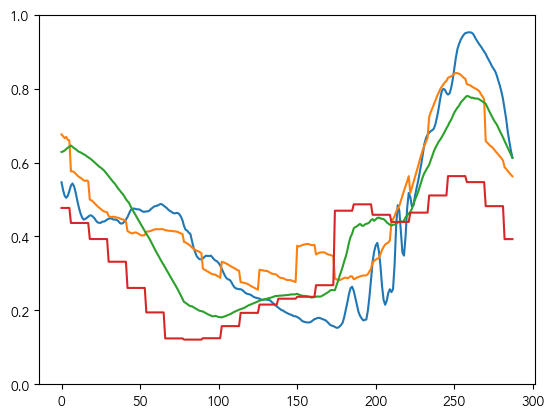

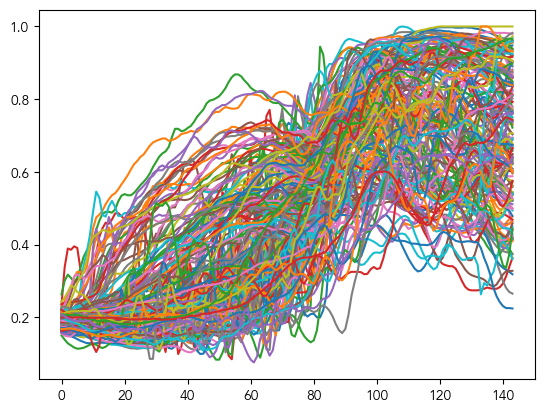

In [239]:
day = 200
asset = 10
interval = 144

_fdu = functional_dynamic_update(
    _distances = {"temporal": "seasonal_equinox", "spatial": "haversine"},
    name = assets_ts_[asset],
    date = T_ts_[day, interval],
)
print(_fdu.name, _fdu.date)

# Filter solar hours with loading solar set
interval_mask = mask_intervals(F_tr_, E_tr_bias_, t_tr_, day, day_window=7)

_fdu.fit(
    F_tr_,
    E_tr_lin_,
    dt_,
    X_=X_tr_,
    t_=t_tr_,
    interval_mask=interval_mask,
    n_samples_per_hour=12,
)

# M_ = _fdu.predict(F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset], X_ts_[asset, :], t_ts_[day],
#                   forget_rate_f = _get_hyper(hyper_, 'forget_rate_f', interval),
#                   forget_rate_e = _get_hyper(hyper_, 'forget_rate_e', interval),
#                   length_scale_f = _get_hyper(hyper_, 'length_scale_f', interval),
#                   length_scale_e = _get_hyper(hyper_, 'length_scale_e', interval),
#                   lookup_rate = _get_hyper(hyper_, 'lookup_rate', interval),
#                   trust_rate = _get_hyper(hyper_, 'trust_rate', interval),
#                   nu = _get_hyper(hyper_, 'nu', interval),
#                   gamma = _get_hyper(hyper_, 'gamma', interval),
#                   xi = _get_hyper(hyper_, 'xi', interval),
#                   kappa = _get_hyper(hyper_, 'kappa', interval),
#                   p_fusion = _get_hyper(hyper_, 'p_fusion', interval))
# 0.0625	0.0625	0.028060214	0.006827178	20.99145857	4.29436436	0.05	0.95	90
# 0.0625	24	2	0.342348791	0.633439596
M_ = _fdu.predict(
    F_ts_[day, :interval, asset],
    E_ts_lin_[day, :, asset],
    X_ts_[asset, :],
    t_ts_[day],
    forget_rate_f=0.0625,
    forget_rate_e=0.0625,
    length_scale_f=0.0025,
    length_scale_e=0.1,
    lookup_rate=24,
    nu=2,
    trust_rate=0.35,
    xi=0.65,
    gamma=75,
    kappa=175,
    p_fusion=0.75,
)

print(_fdu.idx_neighbors_.shape)
print(_fdu.idx_temporal_.shape)
print(_fdu.idx_spatial_.shape)

# Plotting variables
e_ = E_ts_[day, :, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_biased_ = E_ts_biased_[day, :, asset]
f_ = F_ts_[day, :interval, asset]
f_hat_ = F_ts_[day, interval:, asset]
x_ts_ = X_ts_[asset, :]

file_name = f"{resource}-{asset}-{day}-{interval}-asset"
print(file_name)

plt.figure()
plt.plot(F_ts_[day, :, asset])
plt.plot(e_)
plt.plot(e_lin_)
plt.plot(e_bias_)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(M_.T)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


155 (155, 144)
155 (155, 144)
155 (155, 144)
147 (147, 144)


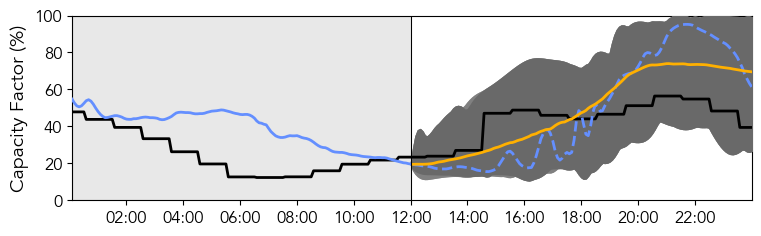

In [234]:
# Samples in each confidence band
dist = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
# _depth = IntegratedDepth()
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(subsample=12, n_basis=20)

J_ = _fdu.focal_curve_envelope(_depth, M_int_, dist,)

k_ = _get_band_fraction(envelope_, alpha_, dist, interval)

f_focal_ext_, _upper, _lower = _fdu.focal_envelop_confidence_bands(alpha_, k_)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelop(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_biased_, dt_ + 5, dx_, interval,
    color=palette_.loc[4, "ibm"],
    label=r"$\bar{f} (s)$",
    CR="CR",
    range_=[0, 287],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon=False,
    loc=(0.1875, 0.825),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=5,
)

plt.savefig(IMAGES / f"focal_curve_envelop-{file_name}.pdf")

plt.show()

# Visualization Utils

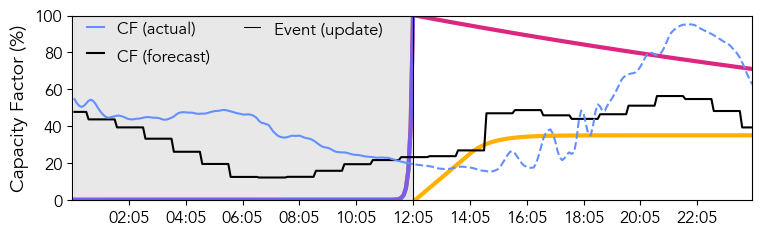

In [235]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_forecast_parameters(
    _fig, _ax, palette_,
    _fdu.phi_, _fdu.psi_, _fdu.eta_,
    f_, f_hat_, e_bias_, dx_, dt_ + 5, interval,
    range_=[0, 287],
    labels_1=True,
    labels_2=False,
)

_ax.legend(frameon=False,
           ncol=2,
           loc=(0.0125,0.7),
           #loc=(0.362,0.625),
           fontsize=12)

plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

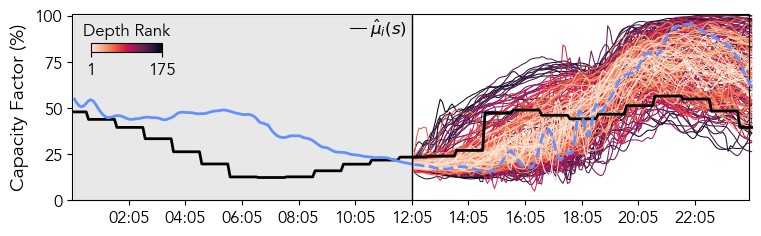

In [236]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

depth = "MBD"
depth_rank_ = _fDepth(_fdu.M_int_ds_, depth, DEPTH).to_numpy()[:, 0]

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_bias_, depth_rank_, dx_, dt_ + 5, interval,
    range_=[0, 287],
    colorbar=True,
)

_ax.legend(frameon = False,
           loc = (0.4, .825),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.2,
           ncol = 5)

plt.savefig(IMAGES / f"ranking-{depth}_{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


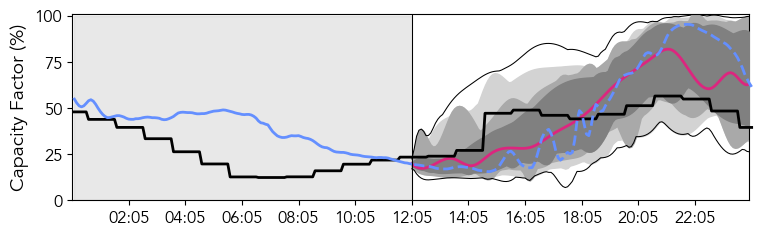

In [218]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(M_int_, depth_rank_)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_bias_, dt_, dx_, interval,
    range_=[0, 287],
    legend_1=False,
    legend_2=False,
)

_ax.legend(frameon = False,
           loc = (0.1875, .825),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.2,
           ncol = 6)

plt.savefig(IMAGES / f"fboxplot-{depth}_{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


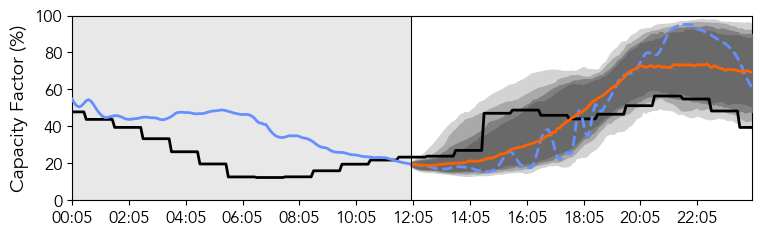

In [219]:
# Calculate confidence intervals from Directional Quantiles
f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(M_int_, alpha_)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelop(
    _fig, _ax, palette_,
    _upper, _lower, f_median_ext_, f_, f_hat_, e_bias_, dt_, dx_, interval,
    color=palette_.loc[3, "ibm"],
    CR="CI",
    label=r"$\bar{\mu} (s)$",
    range_=[0, 287],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .825),
    fontsize = 12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol = 5
)

plt.savefig(IMAGES / f"EDF-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


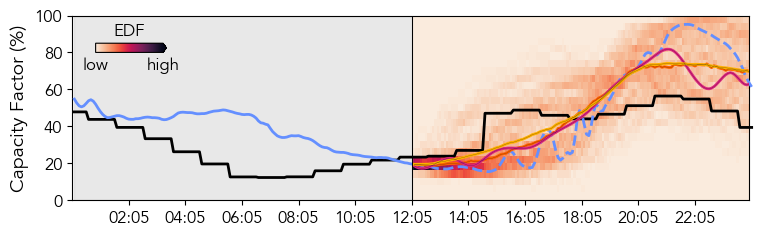

In [220]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_density_heatmap(
    _fig, _ax, palette_,
    M_, _fdu.f_median_ext_, f_deepest_ext_, _fdu.f_focal_ext_,
    f_, f_hat_, e_bias_, dx_, dt_, interval,
    range_=[0, 287],
    colorbar=True,
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .8),
    fontsize = 12,
    ncol = 3
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

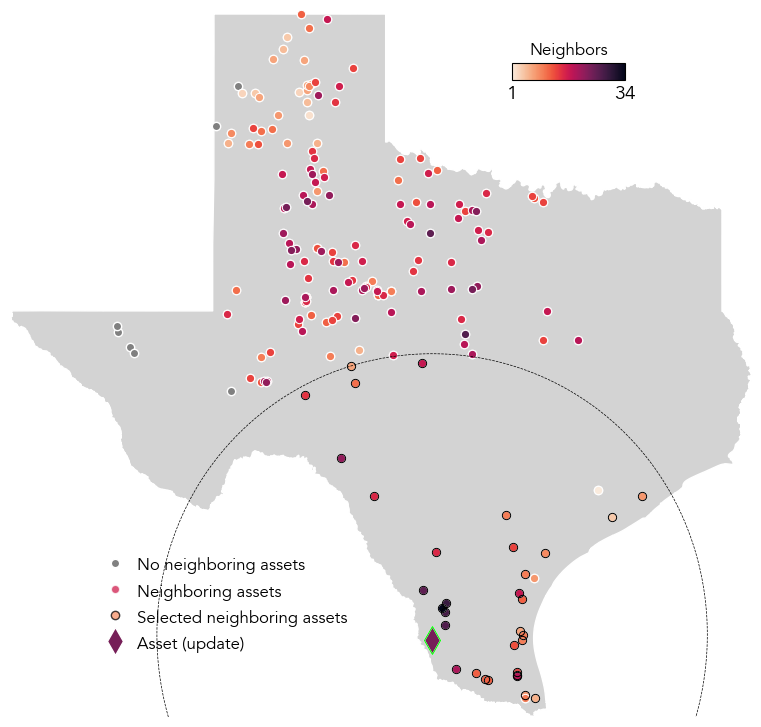

In [196]:
_fig, _ax = plt.subplots(figsize=(7.5, 7.5), constrained_layout=True)

plotter.plot_frequency_map(
    _fig, _ax, palette_, 
    _TX, _fdu, X_tr_, X_ts_, _fdu.x_, _fdu.idx_neighbors_,
    _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.sigma,
)

_ax.legend(
    frameon=False, 
    bbox_to_anchor=(0.475, 0.25), 
    ncol=1, 
    fontsize=12
)

plt.savefig(IMAGES / f"spatial_neiboring_assets-{file_name}.pdf")

plt.show()

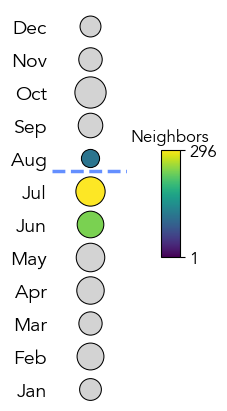

In [214]:
_fig, _ax = plt.subplots(figsize=(2, 4), constrained_layout=True)

plotter.scenarios_frequency_dates(
    _fig, _ax, palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_,
    T_tr_[:, interval], _fdu.date,
    scale=1.5,
    colorbar=True,
)

plt.savefig(IMAGES / f"temporal_neiboring_assets-{file_name}.pdf")

plt.show()

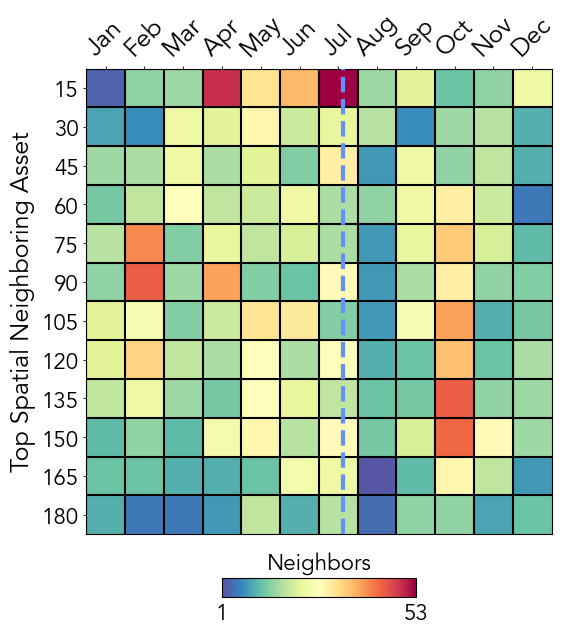

In [187]:
fig, _ax = plt.subplots(figsize=(7.5, 6.25), constrained_layout=True)

plotter.selected_scenarios_heatmap(
    _fig, _ax, palette_,
    _fdu._haversine_dist, _fdu.idx_neighbors_, _fdu.d_spatial_,
    _fdu.x_, T_tr_[:, interval], X_ts_,
    _fdu.date,
    colorbar=True,
)

plt.savefig(IMAGES / f"seasonly_neiboring_assets-{file_name}.pdf")

plt.show()

75
0.12508679939771572
42.0


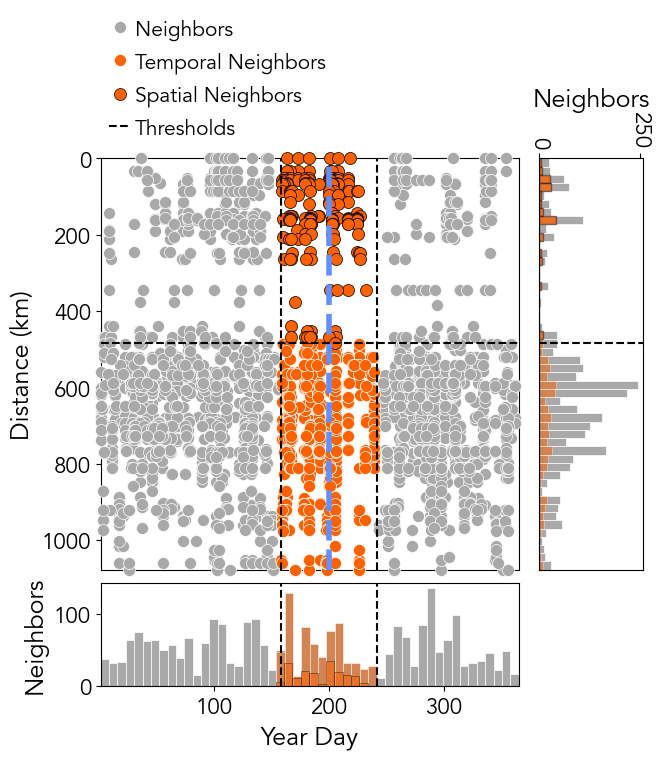

In [245]:
_fig, _ax = plt.subplot_mosaic(
    [["A", "B"], ["C", "."]],
    figsize=(6.5, 7.5),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(1, 0.25), height_ratios=(1, 0.25)),
)

plotter.plot_filtered_scenarios(
    _fig, _ax["A"], palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.d_spatial_,
    t_tr_, t_ts_[day], _fdu.sigma, _fdu.window, _fdu.gamma_prime,
)

plotter.plot_distance_histogram(
    _fig, _ax["B"], palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_,
    _fdu.d_spatial_, _fdu.sigma,
)

plotter.plot_dates_histogram(
    _fig, _ax["C"], palette_,
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.d_spatial_,
    t_tr_, t_ts_[day], _fdu.window, _fdu.gamma_prime,
)

_ax["A"].legend(
    frameon=False,
    ncol=1,
    columnspacing=0.625,
    handletextpad=0.25,
    loc=(0.0, 1.025),
    fontsize=15,
)

plt.savefig(IMAGES / f"kNN_frequency-{file_name}.pdf")

plt.show()

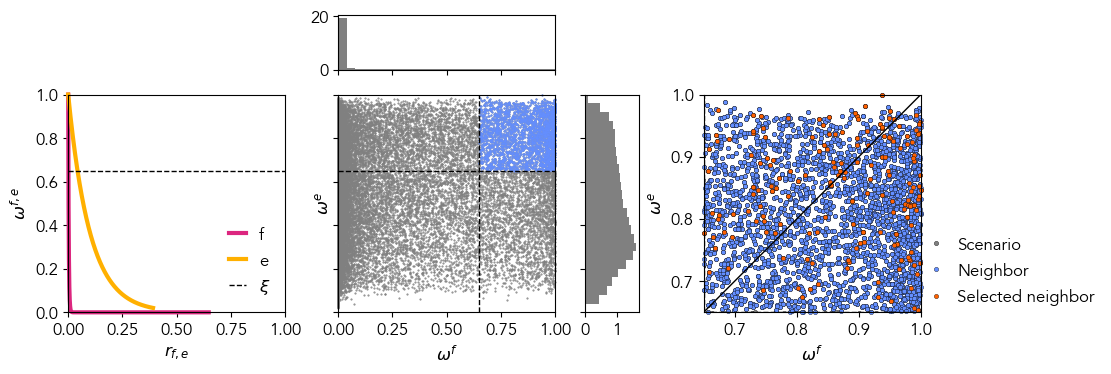

In [164]:
fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, _ax["A"], palette_, 
    _fdu.d_f_, _fdu.d_e_, _fdu.w_f_, _fdu.w_e_, _fdu.xi)

plotter.plot_functional_neighborhood(
    _fig, _ax["B"], _ax["e"], _ax["f"], palette_, 
    _fdu.idx_neighbors_, _fdu.w_f_, _fdu.w_e_, _fdu.xi
)

plotter.plot_selected_functional_neighbors(
    _fig, _ax["C"], palette_, _fdu.idx_neighbors_, _fdu.idx_temporal_,
    _fdu.idx_spatial_, _fdu.w_f_, _fdu.w_e_, _fdu.w_, _fdu.xi,
)

_ax["C"].legend(
    frameon=False, 
    fontsize=12, 
    ncol=1, 
    loc=(1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor-{file_name}.pdf")

plt.show()

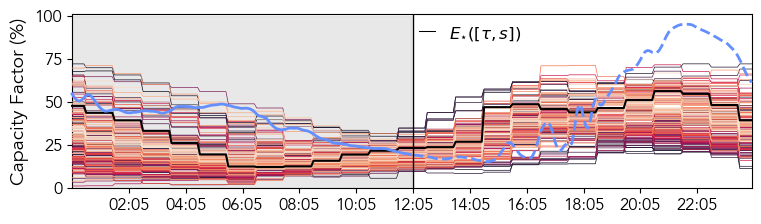

In [221]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_forecasts(
    _fig, _ax, palette_, E_tr_biased_, _fdu.w_, _fdu.idx_spatial_, 
    f_, f_hat_, e_bias_, dx_, dt_ + 5, interval,
    range_=[0, 287],
    legend=False,
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

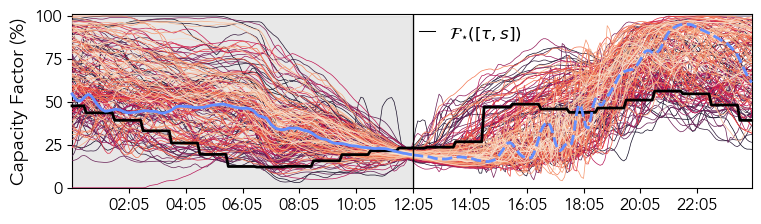

In [222]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_neighbors(
    _fig, _ax, palette_, F_tr_, _fdu.w_, _fdu.idx_spatial_, 
    f_, f_hat_, e_bias_, dx_, dt_, interval,
    range_=[0, 287],
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

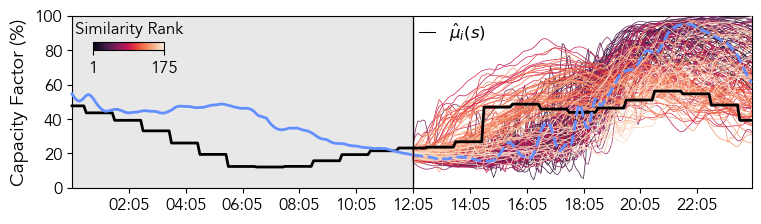

In [223]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_updates(
    _fig, _ax, palette_, M_, f_, f_hat_, e_bias_, 
    _fdu.w_, _fdu.idx_spatial_, dx_, dt_, interval,
    range_=[0, 287],
)

_ax.legend(
    loc=(0.5, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

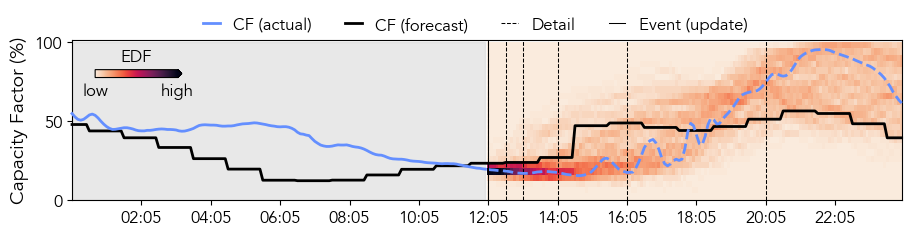

In [152]:
slices_ = [6, 12, 24, 48, 96]

_fig, _ax = plt.subplots(figsize=(9, 2.25), constrained_layout=True)

plotter.plot_heatmap_slices(
    _fig, _ax, palette_, _fdu.M_, f_, f_hat_, 
    e_biased_, dx_, dt_, interval,
    slices_ = slices_,
    range_ = [0, 287],
    colorbar = True,
)

_ax.legend(
    loc=(0.15, 1), 
    frameon=False, 
    fontsize=12, 
    ncol=4
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

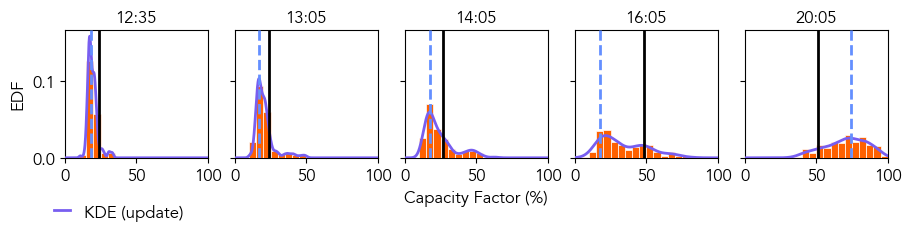

In [153]:
KDs_ = _fdu.kernel_density_estimation(100.*M_, algorithm="auto", kernel="gaussian")

_fig, _ax = plt.subplots(
    1, len(slices_), 
    figsize=(9, 2.25), 
    sharey=True, 
    layout="constrained"
)

plotter.plot_histogram_cuts(
    _fig, _ax, palette_, 
    KDs_, M_, f_, f_hat_, e_biased_, dx_, dt_, interval, 
    slices_ = slices_)

_ax[0].legend(
    frameon=False, 
    fontsize=12, 
    loc=(-0.125, -0.55)
)

plt.savefig(IMAGES / f"marginal_density_cutoffs-{file_name}.pdf")

plt.show()

In [229]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for interval in range(12, 276, 12):

    M_ = _fdu.predict(
        F_ts_[day, :interval, asset],
        E_ts_lin_[day, :, asset],
        X_ts_[asset, :],
        t_ts_[day],
        forget_rate_f=_get_hyper(hyper_, "forget_rate_f", interval),
        forget_rate_e=_get_hyper(hyper_, "forget_rate_e", interval),
        length_scale_f=_get_hyper(hyper_, "length_scale_f", interval),
        length_scale_e=_get_hyper(hyper_, "length_scale_e", interval),
        lookup_rate=_get_hyper(hyper_, "lookup_rate", interval),
        trust_rate=_get_hyper(hyper_, "trust_rate", interval),
        nu=_get_hyper(hyper_, "nu", interval),
        gamma=_get_hyper(hyper_, "gamma", interval),
        xi=_get_hyper(hyper_, "xi", interval),
        kappa=_get_hyper(hyper_, "kappa", interval),
        p_fusion=_get_hyper(hyper_, "p_fusion", interval),
    )

    # Compute depth to find the focal curve
    _F = FDataGrid(data_matrix=_fdu.M_, grid_points=_fdu.dt_[interval:])

    depth_rank_ = np.argsort(_depth(_F))[::-1]

    M_curves_.append(np.median(_fdu.M_, axis=0))
    F_curves_.append(_fdu.f_focal_)
    D_curves_.append(_fdu.M_[depth_rank_[0], :])

print(len(F_curves_), len(M_curves_), len(D_curves_))

22 22 22


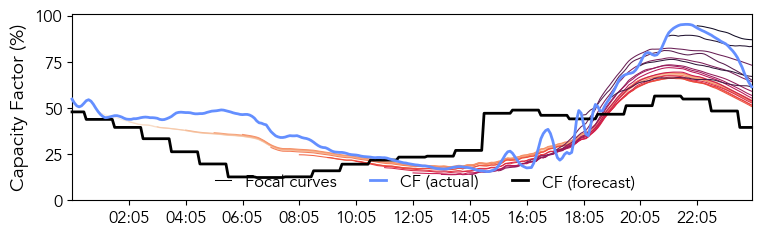

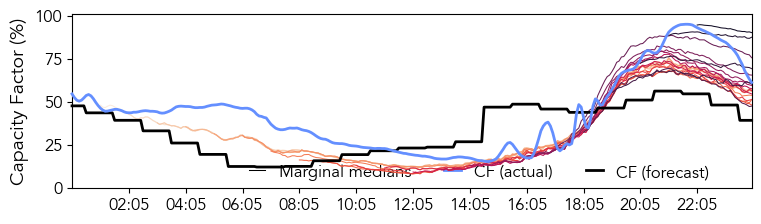

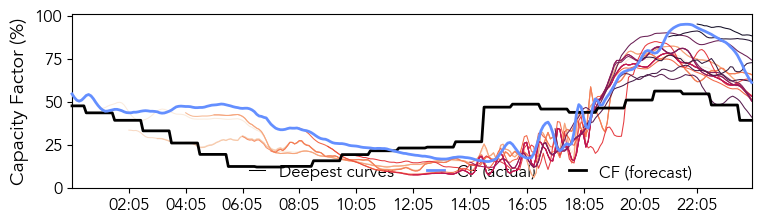

In [231]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    F_curves_, f_, f_hat_, e_biased_, dx_, dt_,
    label="Focal curves",
    range_=[0, 287],
    legend=True,
    colorbar=False,
)

_ax.legend(
    loc=(0.2, 0.0125), 
    frameon=False, 
    fontsize=12, 
    ncol=3
)

plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    M_curves_, f_, f_hat_, e_biased_, dx_, dt_, 
    range_=[0, 287],
    legend=True,
    colorbar=False,
    label="Marginal medians"
)

_ax.legend(
    loc=(0.25, 0.0), 
    frameon=False, 
    fontsize=12, 
    ncol=3
)

plt.savefig(IMAGES / f"dynamic_update-median_marginals-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    D_curves_, f_, f_hat_, e_bias_, dx_, dt_, 
    range_=[0, 287],
    legend=True,
    colorbar=False,
    label="Deepest curves"
)

_ax.legend(
    loc=(0.25, 0.0), 
    frameon=False, 
    fontsize=12, 
    ncol=3
)

plt.savefig(IMAGES / f"dynamic_update-deepest_curve-{file_name}.pdf")

plt.show()

(67881,) (168,) (647, 2) (168, 2)


 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning:__len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning:Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning:__getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 <__array_function__ internals>:5: ShapelyDeprecationWarning:The array interface is deprecated and will

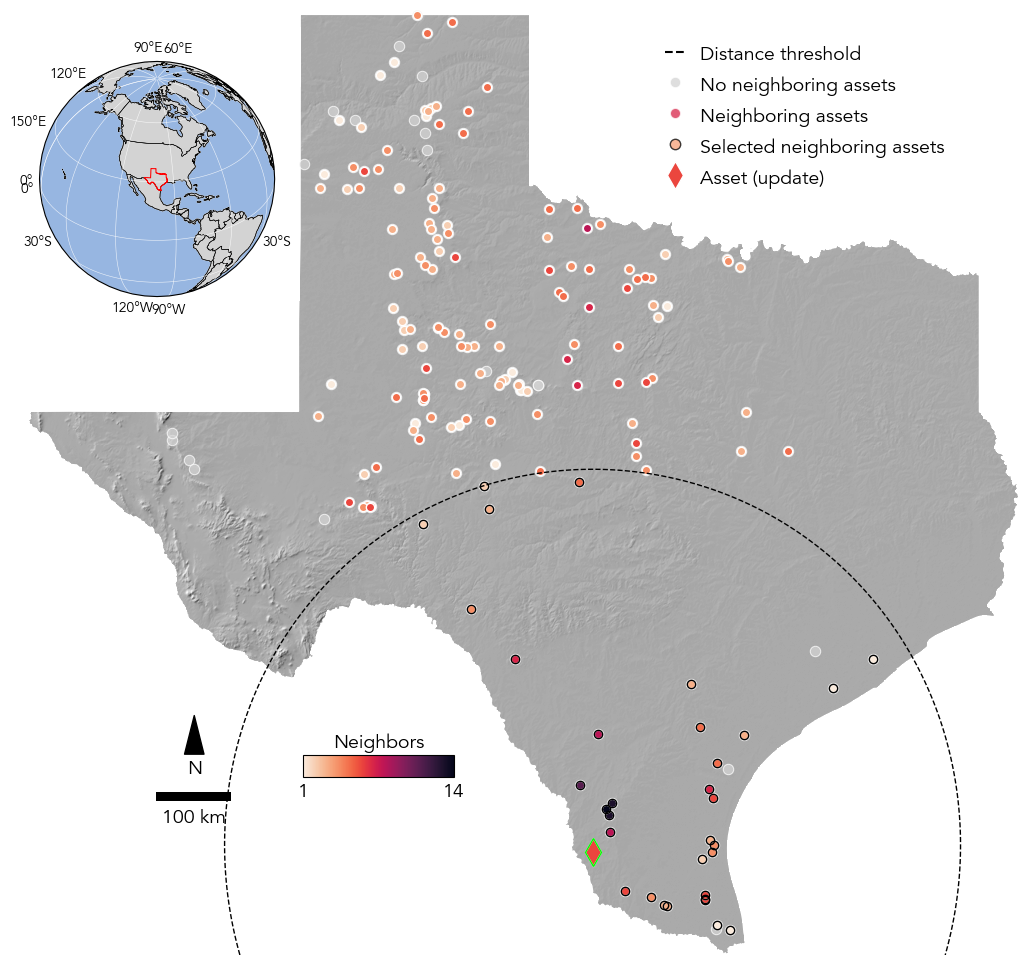

In [201]:
_fig, _ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")

# Add an inset globe showing Texas
plotter.globe_inset(
    _fig, _ax, _TX, 
    x0=0.005, 
    y0=0.7, 
    width=0.25, 
    height=0.25
)

_fig, _ax = plotter.hillshade(_fig, _ax, _TX)

plotter.plot_hillshade_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, _fdu.x_, 
    _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_, _fdu.sigma,
)

# Add compass (North arrow)
x = 0.1675
y = 0.2575
arrow_length = 0.06  # relative axes coords

_ax.annotate(
    "N",
    xy=(x, y),
    xytext=(x, y - arrow_length),
    arrowprops=dict(facecolor="k", 
                    arrowstyle="wedge,tail_width=1,shrink_factor=.5"),
    ha="center",
    va="center",
    fontsize=14,
    xycoords=_ax.transAxes,
)

scalebar = ScaleBar(
    dx=100,  # scaling factor
    units="km",
    dimension="si-length",  # could also be 'imperial-length.'
    location="lower left",
    length_fraction=0.09,  # fraction of the axis for bar length
    color="black",
    box_color="None",
    box_alpha=1.0,
    border_pad=9,
    font_properties={"size": 14},
)

_ax.add_artist(scalebar)

_ax.legend(
    frameon=False, 
    bbox_to_anchor=(0.625, 0.9875), 
    ncol=1, 
    fontsize=14
)

plt.savefig(IMAGES / f"hillshade_neighboring_assets-{file_name}.pdf")

plt.show()

-0.11719467401285566 0.13965411692684415
[ 0.13965412 -0.08115243 -0.05031374 -0.05880777  0.09500306  0.10449189
  0.02720386 -0.0404423  -0.11719467 -0.018442  ]


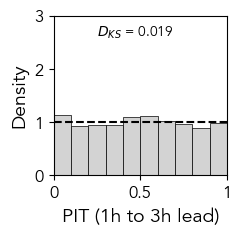

-0.11015457606366674 0.3146235078053259
[ 0.31462351 -0.03917968 -0.0479798  -0.11015458 -0.09217172 -0.04315886
 -0.04090144  0.03676921 -0.04893633  0.07108968]


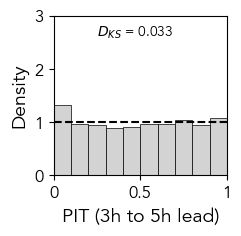

In [35]:
# def clean_fmt(x, pos):
#     if abs(x - round(x)) < 1e-9:
#         return str(int(round(x)))
#     return f"{x:.2g}"

# def _plot_PIT(_ax, u_,
#               bins=10,
#               v=0.5,
#               xlabel = 'PIT'):

#     vmin= -v
#     vmax= v

#     KS_stat = _KS(u_)
#     u_ = np.sort(u_)
#     n = len(u_)

#     # --- Histogram ---
#     counts_, bins_, patches = _ax.hist(u_,
#                                        bins=bins,
#                                        range=(0.0, 1.0),
#                                        density=True,
#                                        lw=0.5,
#                                        edgecolor='k',
#                                        alpha=1)

#     # deviation from perfect calibration
#     deviation = counts_ - 1.
#     #print(deviation.min(), deviation.max())
#     #print(deviation)

#     # --- Colormap centered at 0 ---
#     norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

#     cmap = cm.get_cmap("coolwarm")

#     for patch, dev in zip(patches, deviation):
#         #patch.set_facecolor(cmap(norm(dev)))
#         patch.set_facecolor('lightgray')

#     # --- Reference line ---
#     _ax.axhline(1.0,
#                 c = 'k',
#                 linestyle='--')

#     _ax.set_xlim(0, 1)
#     _ax.set_ylim(0, 3)

#     #_ax.set_xlabel("u = F̂(y_obs)")
#     _ax.set_xlabel(xlabel, size=14)
#     _ax.set_ylabel("Density", size=14)

#     _ax.xaxis.set_major_formatter(FuncFormatter(clean_fmt))

#     _ax.tick_params(axis="both", labelsize=12)

#     # --- Annotate KS statistic ---
#     _ax.text(0.25, 0.95,
#              f"$D_{{KS}}$ = {KS_stat:.3f}",
#              transform=_ax.transAxes,
#              verticalalignment='top')


# time = 72

# U_ = pd.read_csv(path_to_validation + f"/{resource}_fusion_{time}_ts.csv",
#                  low_memory=False).to_numpy()

# _fig, _ax = plt.subplots(1, 1,
#                         figsize = (2.3, 2.25),
#                         layout  = "constrained")

# lead = 0
# bins = 10
# _plot_PIT(_ax, U_[:, lead*12:(lead + 3)*12].flatten(), bins,
#           xlabel = 'PIT (1h to 3h lead)')

# plt.savefig(path_to_images + f"/PIT-{resource}-{lead}-{bins}-{time}.pdf",
#             bbox_inches = "tight")

# plt.show()

# _fig, _ax = plt.subplots(1, 1,
#                         figsize = (2.3, 2.25),
#                         layout  = "constrained")

# lead = 3

# _plot_PIT(_ax, U_[:, lead*12:(lead + 3)*12].flatten(), bins,
#           v = 0.4,
#           xlabel = 'PIT (3h to 5h lead)')

# plt.savefig(path_to_images + f"/PIT-{resource}-{lead}-{bins}-{time}.pdf",
#             bbox_inches = "tight")

# plt.show()